In [28]:
# this file to get data from mongoDB
from pymongo.mongo_client import MongoClient
from pymongo.server_api import ServerApi
from dotenv import load_dotenv
import os
import json
import matplotlib.pyplot as plt

In [29]:
# to get environment vars
load_dotenv()

True

In [30]:
# connect to the database
uri = os.getenv('MONGODB_CONNECTION_STRING')
client = MongoClient(uri, server_api=ServerApi('1'))

In [31]:
# Send a ping to confirm a successful connection
try:
  client.admin.command("ping")
  print("You successfully connected to MongoDB!")
except Exception as e:
  print(e)

You successfully connected to MongoDB!


In [32]:
db = client['Hotel'] # access database
collection = db['Hotel'] # access collection in a database

In [33]:
# create index on city field for faster querying
# collection.create_index({'city': 1})

# another one for title as it is queried frequently
# collection.create_index({'title': 1})

### Getting data for wordCloud

In [34]:
# get and concat all comments description
data1 = collection.aggregate([{
  '$project': {
    'comments.description': 1, 
    '_id': 0,
  },
}])

In [35]:
# print fetched data
text = ''
for obj in data1:
  for desc in obj['comments']:
    text += desc['description']
text

"We had a lovely stay at Serry Beach Resort. The property is beautiful, with a stunning pool and beach that made for the perfect relaxation spot. The atmosphere was peaceful, and the staff were friendly and welcoming. We truly enjoyed our time here...The service was top, and everyone was happy and friendly.\nFatima at the reception went out of her to see that we get the best room.\nThere was a variety of food dishes, so many options to choose. The best part was late breakfast and lunch for those...I loved how clean this property was, the great food, the accommodating staff, the entertainment timetable, the large single beds that could comfortably fit in two people, the clean beach, the view from my room… I could go on and onAmazing location at the beach with beautiful long pool and sun chairs. Breakfast offers large variety and is tasty.One of the best resorts in Hurghada recommend it to everyone going thereIt was clean, beautiful, scenic, peaceful, aesthetic, vibes were immaculate and

In [36]:
from nltk.corpus import stopwords
stops = set(stopwords.words('english'))

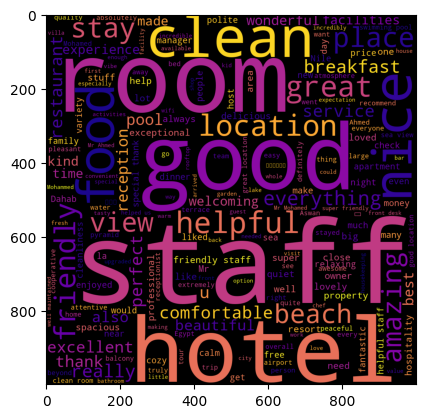

<Figure size 800x800 with 0 Axes>

In [37]:
from wordcloud import WordCloud
cloud = WordCloud(width=1000, height=1000, stopwords=stops, colormap='plasma').generate(text)
plt.imshow(cloud)
plt.figure(figsize=(8, 8))
plt.show()

In [38]:
len(text)

243910

In [39]:
data2 = collection.aggregate([
  {
  '$match': {
    'city': {
        '$exists': True,
        '$ne': None
      }
    },
  },{
  '$group': {
    '_id': '$city', 
    'count': {
      '$sum': 1
    },
    'avg_rating': {
      '$avg': {
        '$ifNull': ['$rating', 0]
      }
    },
    'avg_price': {
      '$avg': {
        '$ifNull': ['$price', 0]
      }
    },
    'latitude': {
      '$avg': {
        '$ifNull': ['$latitude', 0]
      }
    },
    'longitude': {
      '$avg': {
        '$ifNull': ['$longitude', 0]
      }
    },
  },
}])

In [40]:
for obj in data2:
  print(obj)

{'_id': 'Dahab', 'count': 24, 'avg_rating': 8.25, 'avg_price': 326.5833333333333, 'latitude': 28.49722488437615, 'longitude': 34.51161868407057}
{'_id': 'Marsa Alam', 'count': 22, 'avg_rating': 9.004545454545454, 'avg_price': 548.0909090909091, 'latitude': 25.231095092333693, 'longitude': 34.8007862526018}
{'_id': 'North Coast', 'count': 3, 'avg_rating': 9.166666666666666, 'avg_price': 462.0, 'latitude': 30.962679019288046, 'longitude': 28.507248818801813}
{'_id': 'Ismailia', 'count': 15, 'avg_rating': 4.6066666666666665, 'avg_price': 1958.6666666666667, 'latitude': 30.57893314520411, 'longitude': 32.26821127187109}
{'_id': 'Hurghada', 'count': 31, 'avg_rating': 6.867741935483871, 'avg_price': 519.3225806451613, 'latitude': 27.6837049071689, 'longitude': 33.54326616436688}
{'_id': 'Aswan', 'count': 25, 'avg_rating': 8.092, 'avg_price': 512.32, 'latitude': 24.089226775766093, 'longitude': 32.882503765847844}
{'_id': 'Cairo', 'count': 26, 'avg_rating': 5.438461538461539, 'avg_price': 292

In [41]:
data3 = collection.aggregate([
  {'$unwind': '$facilities'}, # deconstruct array elements
  {
    '$group': {
      '_id': '$facilities',
      'count': {
        '$sum': 1
      },
      'avg_rating': {
        '$avg': {
          '$ifNull': ['$rating', 0]
        }
      },
      'avg_price': {
        '$avg': {
          '$ifNull': ['$price', 0]
        } 
      }
    }
  }
])

In [42]:
for obj in data3:
  print(obj)

{'_id': 'Fitness center', 'count': 63, 'avg_rating': 7.850793650793651, 'avg_price': 954.2698412698413}
{'_id': '3 swimming pools', 'count': 16, 'avg_rating': 8.3125, 'avg_price': 423.25}
{'_id': 'Family rooms', 'count': 161, 'avg_rating': 7.3105590062111805, 'avg_price': 571.4534161490683}
{'_id': 'Wifi', 'count': 4, 'avg_rating': 6.75, 'avg_price': 410.75}
{'_id': 'Free parking', 'count': 174, 'avg_rating': 6.9045977011494255, 'avg_price': 675.3735632183908}
{'_id': 'Swimming pool', 'count': 7, 'avg_rating': 1.5, 'avg_price': 237.57142857142858}
{'_id': '2 restaurants', 'count': 18, 'avg_rating': 7.811111111111111, 'avg_price': 299.6111111111111}
{'_id': 'Excellent Breakfast', 'count': 15, 'avg_rating': 8.78, 'avg_price': 643.6666666666666}
{'_id': '9 swimming pools', 'count': 3, 'avg_rating': 6.566666666666667, 'avg_price': 0.0}
{'_id': 'Very Good Breakfast', 'count': 28, 'avg_rating': 8.325, 'avg_price': 795.4285714285714}
{'_id': 'Good free Wifi (26 Mbps)', 'count': 1, 'avg_rating

In [43]:
data4 = collection.aggregate([
  {
    '$match': {
      'rating': {
        '$exists': True,
        '$ne': None
      }
    }
  },
  {'$project': {
      'rating_details': 1,
      'title': 1,
      '_id': 0,
      'rating': 1
    }
  },
])

In [44]:
for obj in data4:
  print(obj)

{'title': 'Serry Beach Resort', 'rating': 8.8, 'rating_details': {'Staff': 8.8, 'Facilities': 9.0, 'Cleanliness': 9.2, 'Comfort': 9.2, 'Value for money': 8.3, 'Location': 9.3, 'Free Wifi': 9.4}}
{'title': 'Andalusia Blue Beach Hurghada', 'rating': 7.5, 'rating_details': {'Staff': 8.4, 'Facilities': 7.2, 'Cleanliness': 7.5, 'Comfort': 7.5, 'Value for money': 8.1, 'Location': 8.8, 'Free Wifi': 5.6}}
{'title': 'Elaria Hotel Hurgada', 'rating': 7.4, 'rating_details': {'Staff': 8.6, 'Facilities': 7.3, 'Cleanliness': 7.5, 'Comfort': 7.5, 'Value for money': 7.9, 'Location': 8.2, 'Free Wifi': 9.2}}
{'title': 'Royal City Hotel', 'rating': 6.6, 'rating_details': {'Staff': 7.5, 'Facilities': 6.5, 'Cleanliness': 6.7, 'Comfort': 7.2, 'Value for money': 7.2, 'Location': 8.4, 'Free Wifi': 3.2}}
{'title': 'Juliana Beach Resort by VISION HURGHADA', 'rating': 6.6, 'rating_details': {'Staff': 7.7, 'Facilities': 7.0, 'Cleanliness': 6.7, 'Comfort': 7.0, 'Value for money': 7.0, 'Location': 6.9}}
{'title': '

In [45]:
data5 = collection.aggregate([
  {
    '$group': {
      '_id': '$title',
      'avg_rating': {
        '$avg': {
          '$ifNull': ['$rating', 0]
        }
      },
      'avg_price': {
        '$avg': {
          '$ifNull': ['$price', 0]
        } 
      }
    }
  }
])

In [46]:
for obj in data5:
  print(obj)

{'_id': 'Blue Lotus Nile Suites Hotel Aswan', 'avg_rating': 7.6, 'avg_price': 1155.0}
{'_id': 'Noras Beach Hotel', 'avg_rating': 7.5, 'avg_price': 2309.0}
{'_id': 'JAZ Neo Ivory', 'avg_rating': 8.3, 'avg_price': 0.0}
{'_id': 'Tunis Camp Fayoum', 'avg_rating': 8.2, 'avg_price': 1848.0}
{'_id': 'Utopia Beach Club', 'avg_rating': 8.7, 'avg_price': 0.0}
{'_id': 'Ismailia', 'avg_rating': 0.0, 'avg_price': 0.0}
{'_id': '4S Hotel Dahab', 'avg_rating': 8.1, 'avg_price': 0.0}
{'_id': 'B1-04 Juliana', 'avg_rating': 0.0, 'avg_price': 3239.0}
{'_id': 'Shams Hotel & Dive Centre', 'avg_rating': 8.9, 'avg_price': 0.0}
{'_id': 'شقة مفروشة للايجار', 'avg_rating': 0.0, 'avg_price': 0.0}
{'_id': 'Marassi', 'avg_rating': 0.0, 'avg_price': 0.0}
{'_id': 'Tolip Resort El Galala Majestic', 'avg_rating': 7.6, 'avg_price': 0.0}
{'_id': 'Nebro Nubian Guest House - Adults Only', 'avg_rating': 9.5, 'avg_price': 0.0}
{'_id': 'Palm Geust House', 'avg_rating': 9.4, 'avg_price': 0.0}
{'_id': 'bella vita- city center- 

In [47]:
data6 = collection.aggregate([
  {'$unwind': '$comments'},
  {
    '$group': {
      '_id': '$comments.country',
      'count': {
        '$sum': 1
      }
    }
  },
  {
    '$match': {
      '_id': {
        '$regex': r'\w{2,}'
      }
    }
  },
  {
    '$sort': {
      'count': 1
    }
  }
])

In [48]:
for obj in data6:
  print(obj)

{'_id': 'Lebanon', 'count': 1}
{'_id': 'Costa Rica', 'count': 1}
{'_id': 'Tunisia', 'count': 1}
{'_id': 'Iraq', 'count': 1}
{'_id': 'Latvia', 'count': 1}
{'_id': 'Estonia', 'count': 1}
{'_id': 'Serbia', 'count': 1}
{'_id': 'Libya', 'count': 1}
{'_id': 'Laos', 'count': 1}
{'_id': 'Georgia', 'count': 1}
{'_id': 'Trinidad and Tobago', 'count': 1}
{'_id': 'Morocco', 'count': 1}
{'_id': 'Malta', 'count': 1}
{'_id': 'Ecuador', 'count': 1}
{'_id': 'Moldova', 'count': 1}
{'_id': 'Greece', 'count': 1}
{'_id': 'Sudan', 'count': 1}
{'_id': 'Norway', 'count': 1}
{'_id': 'Azerbaijan', 'count': 1}
{'_id': 'Yemen', 'count': 1}
{'_id': 'Finland', 'count': 1}
{'_id': 'Panama', 'count': 2}
{'_id': 'Philippines', 'count': 2}
{'_id': 'Mexico', 'count': 2}
{'_id': 'Brazil', 'count': 2}
{'_id': 'Luxembourg', 'count': 2}
{'_id': 'Vietnam', 'count': 2}
{'_id': 'Thailand', 'count': 2}
{'_id': 'Chile', 'count': 2}
{'_id': 'Algeria', 'count': 2}
{'_id': 'Nigeria', 'count': 2}
{'_id': 'Romania', 'count': 2}
{'_id

In [49]:
data7 = collection.aggregate([
  {
    '$match': {
      'price': {
        '$ne': None
      },
      'rating': {
        '$ne': None
      },
    }
  },
  {
    '$project': {
      '_id': 0,
      'rating': 1,
      'price': 1
    }
  }
])

In [50]:
for obj in data7:
  print(obj)

{'price': 1294.0, 'rating': 8.8}
{'price': 1540.0, 'rating': 7.5}
{'price': 739.0, 'rating': 10.0}
{'price': 739.0, 'rating': 4.8}
{'price': 462.0, 'rating': 9.5}
{'price': 2070.0, 'rating': 8.9}
{'price': 3593.0, 'rating': 8.0}
{'price': 873.0, 'rating': 7.6}
{'price': 2160.0, 'rating': 8.8}
{'price': 2703.0, 'rating': 8.4}
{'price': 269.0, 'rating': 7.9}
{'price': 7562.0, 'rating': 7.4}
{'price': 4522.0, 'rating': 8.3}
{'price': 6086.0, 'rating': 7.7}
{'price': 5088.0, 'rating': 7.6}
{'price': 4517.0, 'rating': 7.7}
{'price': 2968.0, 'rating': 8.2}
{'price': 1039.0, 'rating': 10.0}
{'price': 982.0, 'rating': 8.0}
{'price': 1865.0, 'rating': 8.1}
{'price': 2207.0, 'rating': 6.8}
{'price': 1745.0, 'rating': 5.5}
{'price': 2309.0, 'rating': 7.5}
{'price': 3217.0, 'rating': 8.2}
{'price': 924.0, 'rating': 9.4}
{'price': 3945.0, 'rating': 7.3}
{'price': 2883.0, 'rating': 6.7}
{'price': 2515.0, 'rating': 8.2}
{'price': 581.0, 'rating': 7.6}
{'price': 924.0, 'rating': 8.4}
{'price': 1386.0,

In [ ]:
# to close this connection as Free clusters are limited
client.close()